# 피처 × 모델 9조합 검증 — 코드 아래 설명을 따라가기

처음 **100사이클**의 정보로 배터리의 총 `cycle_life`를 예측합니다.
기존 EDA에서 확인한 후보를 아래처럼 비교하며, 성능 개선 여부는 실행 결과로 판단합니다.

| 피처 구성 | 입력 | 비교 모델 3가지 |
|---|---|---|
| A | `log10_delta_q_var` | Ridge 원수명 / Ridge 로그 수명 / ElasticNet 로그 수명 |
| B | `log10_delta_q_var` + `SOC_switch_pct` | 위와 동일 |
| C | `delta_q_min` + `SOC_switch_pct` | 위와 동일 |

**데이터 → 공통 분할 → fit/predict/evaluate → 개발 CV 선택 → Validation → Test → 제출용 nested CV** 순서입니다.
각 코드 셀 바로 아래에 설명이 있습니다. 긴 보조 검증과 nested CV 코드는 접어서 볼 수 있습니다.
기존 [2피처 보고서](https://app.notion.com/p/3ecd54b5a6d7818f99bde98f1cef9db1)의 후보에서 출발하되,
이번 노트북은 `02`나 다른 Python 소스를 실행하지 않는 독립 구성입니다.

## 1. 준비와 바꿔 볼 설정

In [2]:
from pathlib import Path
import hashlib
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

`Ridge`와 `ElasticNet`은 회귀 모델이고, `Pipeline`은 결측 대체·표준화·모델을 순서대로 연결합니다.
`TransformedTargetRegressor`는 학습할 때 수명에 로그를 적용하고 예측할 때 원래 사이클 단위로 되돌립니다.
`GroupShuffleSplit`과 `GroupKFold`는 같은 충전 정책의 셀을 함께 묶어 분할합니다.

In [3]:
SEED = 20261002
TARGET = "cycle_life"
PAPER_TARGET_MAPE = 9.1
FEATURE_SETS = {
    "A": ["log10_delta_q_var"],
    "B": ["log10_delta_q_var", "SOC_switch_pct"],
    "C": ["delta_q_min", "SOC_switch_pct"],
}
MODEL_SPECS = {
    "Ridge_raw": {"model": "Ridge", "target": "identity",
                  "grid": {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}},
    "Ridge_log": {"model": "Ridge", "target": "log",
                  "grid": {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}},
    "ElasticNet_log": {"model": "ElasticNet", "target": "log",
                       "grid": {"alpha": [0.0001, 0.001, 0.01, 0.1],
                                "l1_ratio": [0.1, 0.5, 0.9]}},
}
EXPERIMENT_TO_REPORT = "CV_SELECTED"  # 전체 선택 절차 보고. 고정 실험 예: "B_Ridge_raw"
ALL_INPUTS = ["log10_delta_q_var", "delta_q_min", "SOC_switch_pct"]
pd.set_option("display.max_columns", 20)

**이 셀의 설정을 바꾸고 처음부터 다시 실행하면 됩니다.**
`A/B/C`는 피처 구성, `Ridge_raw/Ridge_log/ElasticNet_log`는 모델·수명 변환 방식입니다.
`grid` 안의 값만 개발 데이터 CV에서 비교합니다. ElasticNet의 `l1_ratio`는 L1 벌점의 비중입니다.
로그 분산과 ΔQ 최솟값은 비슷한 정보를 줄 수 있어, C에서는 로그 분산을 **최솟값으로 교체**합니다.
`EXPERIMENT_TO_REPORT="CV_SELECTED"`이면 마지막 과제 표는 9조합 전체를 고르는 절차를 보고합니다.
예를 들어 `"B_Ridge_raw"`로 바꾸면 기존 2피처 Ridge를 고정한 실험의 6행 표를 볼 수 있습니다.
로그 변환이 항상 성능을 높인다고 가정하지 않습니다.

## 2. 기존 EDA의 세 표 읽기

In [4]:
ROOT = next((p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
             if (p / "data").is_dir() and (p / "results/five_questions").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError("data/와 results/five_questions/가 있는 프로젝트 내부에서 실행하세요.")
SOURCE = ROOT / "results/five_questions"
OUT = ROOT / "Modeling/results/feature_model_validation"
OUT.mkdir(parents=True, exist_ok=True)
metadata = pd.read_csv(SOURCE / "cell_metadata.csv", usecols=[
    "cell_uid", "batch_id", "cycle_life", "charging_policy"])
delta = pd.read_csv(SOURCE / "delta_q_features.csv", usecols=[
    "cell_uid", "batch_id", "cycle_life", "log10_delta_q_var", "delta_q_min", "dq_status"])
current = pd.read_csv(SOURCE / "current_features.csv", usecols=[
    "cell_uid", "batch_id", "cycle_life", "charging_policy", "SOC_switch_pct", "C1", "C2", "policy_suffix"])
print("EDA 입력:", SOURCE)
print("새 결과:", OUT)
display(metadata.head(3), delta.head(3))

EDA 입력: /Users/suyeong/Downloads/archive/results/five_questions
새 결과: /Users/suyeong/Downloads/archive/Modeling/results/feature_model_validation


,batch_id,cell_uid,cycle_life,charging_policy
0,B1,B1_0,1190.0,3.6C(80%)-3.6C
1,B1,B1_1,1179.0,3.6C(80%)-3.6C
2,B1,B1_2,1177.0,3.6C(80%)-3.6C


,cell_uid,batch_id,log10_delta_q_var,delta_q_min,dq_status,cycle_life
0,B1_0,B1,-5.014861,-0.008460,ok,1190.0
1,B1_1,B1,-5.013960,-0.011004,ok,1179.0
2,B1_2,B1,-4.737000,-0.017216,ok,1177.0


한 행은 셀 하나입니다. `cell_uid`로 같은 셀의 메타데이터·ΔQ·충전 정책을 합칩니다.
`ΔQ(V)=Q100(V)−Q10(V)`이며, 로그 분산은 `log10(Var(ΔQ))`, `delta_q_min`은 이 곡선의 최솟값입니다.
두 값 모두 **실제 100사이클을 관측한 뒤** 계산됩니다. `SOC_switch_pct`는 전류 전환 SOC입니다.
결과는 기존 `02`의 결과 폴더와 별도로 저장합니다.

In [5]:
for name, frame in [("metadata", metadata), ("delta", delta), ("current", current)]:
    assert frame["cell_uid"].notna().all(), f"{name}: 셀 식별자 누락"
    assert frame["cell_uid"].is_unique, f"{name}: 중복 셀"
    assert set(frame["cell_uid"]) == set(metadata["cell_uid"]), f"{name}: 셀 목록 불일치"
data = metadata.merge(
    delta.rename(columns={"batch_id": "batch_delta", "cycle_life": "life_delta"}),
    on="cell_uid", how="left", validate="one_to_one",
).merge(
    current.rename(columns={"batch_id": "batch_current", "cycle_life": "life_current",
                            "charging_policy": "policy_current"}),
    on="cell_uid", how="left", validate="one_to_one",
)
for column in ["life_delta", "life_current"]:
    assert np.isclose(data[TARGET], data[column], equal_nan=True).all(), "수명 라벨 불일치"
assert data["batch_id"].eq(data["batch_delta"]).all()
assert data["batch_id"].eq(data["batch_current"]).all()
assert data["charging_policy"].eq(data["policy_current"]).all()
data = data.drop(columns=["batch_delta", "batch_current", "life_delta", "life_current", "policy_current"])

<details><summary>보조 검증: 왜 병합 전에 셀과 라벨을 확인하나요?</summary>

`is_unique`는 셀 중복을, `set(...)` 비교는 파일마다 다른 셀 목록을 확인합니다.
`validate="one_to_one"`는 같은 셀이 여러 행으로 늘어나는 병합을 막습니다.
세 파일의 배치·수명·정책이 일치하는지 확인한 뒤, 중복된 확인용 열만 제거합니다.
`equal_nan=True`는 세 파일에서 모두 수명이 누락된 셀을 같은 상태로 인정한다는 뜻입니다.

</details>

In [6]:
for column in ALL_INPUTS + [TARGET, "C1", "C2"]:
    data[column] = pd.to_numeric(data[column], errors="coerce").replace([np.inf, -np.inf], np.nan)
bad_y = data[TARGET].isna() | data[TARGET].le(0)
bad_delta = data[["log10_delta_q_var", "delta_q_min"]].isna().any(axis=1)
bad_delta |= data["dq_status"].fillna("").ne("ok")
data["eligible"] = ~(bad_y | bad_delta)
data["exclusion_reason"] = [
    "; ".join(reason for condition, reason in [
        (invalid_y, "invalid_or_nonpositive_target"), (invalid_delta, "invalid_delta_q")
    ] if condition) for invalid_y, invalid_delta in zip(bad_y, bad_delta)
]
excluded_cells = data.loc[~data["eligible"]].copy()
cohort_audit = data.groupby("batch_id").agg(
    raw_cells=("cell_uid", "size"), eligible_cells=("eligible", "sum")
).reset_index()
cohort_audit["excluded_cells"] = cohort_audit["raw_cells"] - cohort_audit["eligible_cells"]
data = data.loc[data["eligible"]].drop(columns=["eligible", "exclusion_reason"]).reset_index(drop=True)
display(cohort_audit, excluded_cells[["cell_uid", "exclusion_reason"]])

,batch_id,raw_cells,eligible_cells,excluded_cells
0,B1,46,46,0
1,B2,47,39,8
2,B3,46,44,2


,cell_uid,exclusion_reason
68,B2_22,invalid_or_nonpositive_target
69,B2_23,invalid_or_nonpositive_target
81,B2_35,invalid_or_nonpositive_target
82,B2_36,invalid_or_nonpositive_target
83,B2_37,invalid_or_nonpositive_target
84,B2_38,invalid_or_nonpositive_target
85,B2_39,invalid_or_nonpositive_target
86,B2_40,invalid_or_nonpositive_target
116,B3_23,invalid_or_nonpositive_target
125,B3_32,invalid_or_nonpositive_target


<details><summary>보조 검증: 9조합에 같은 정제 기준을 적용합니다</summary>

숫자가 아닌 값·무한대는 결측으로 통일합니다. 정답이 없거나 0 이하인 셀은 제외하고 **정답은 대체하지 않습니다**.
로그 분산과 ΔQ 최솟값이 모두 유효하고 `dq_status="ok"`인 공통 셀만 비교합니다.
현재 유효 수명 129셀에는 ΔQ 최솟값 결측이 없어 기존 코호트와 동일합니다.
SOC 결측은 여기서 제외하지 않고, 각 학습 폴드의 중앙값으로 대체합니다.
로그 분산이나 ΔQ 최솟값이 음수인 것은 오류를 뜻하지 않습니다.
현재 B1은 46셀, B2는 39셀, B3는 44셀입니다. B3는 EDA 집계에만 남깁니다.

</details>

In [7]:
suffix = data["policy_suffix"].fillna("none").astype(str).str.lower().str.replace(
    r"[^a-z0-9]", "", regex=True).replace("", "none")
raw_policy = data["charging_policy"].fillna("").astype(str).str.lower().str.replace(r"\s+", "", regex=True)
assert raw_policy.ne("").all(), "충전 정책 누락"
data["policy_group"] = [
    f"C1={c1:g}|SOC={soc:g}|C2={c2:g}|suffix={tail}"
    if np.isfinite([c1, soc, c2]).all() else f"raw={raw}"
    for c1, soc, c2, tail, raw in zip(data["C1"], data["SOC_switch_pct"], data["C2"], suffix, raw_policy)
]
batch1 = data.loc[data["batch_id"].eq("B1")].reset_index(drop=True).copy()
batch2 = data.loc[data["batch_id"].eq("B2")].reset_index(drop=True).copy()
assert (len(batch1), len(batch2), batch1["policy_group"].nunique()) == (46, 39, 23)
display(batch1[ALL_INPUTS + [TARGET]].describe())

,log10_delta_q_var,delta_q_min,SOC_switch_pct,cycle_life
count,46.000000,46.000000,46.000000,46.000000
mean,-3.923430,-0.035969,51.521739,844.717391
std,0.378273,0.012945,19.461345,184.629198
min,-5.014861,-0.064720,15.000000,534.000000
25%,-4.053411,-0.044591,40.000000,703.250000
50%,-3.851160,-0.036350,50.000000,858.500000
75%,-3.668210,-0.028561,67.500000,914.250000
max,-3.350338,-0.008460,80.000000,1227.000000


`C1 + SOC + C2 + 접미사`가 같은 충전 정책을 하나의 `policy_group`으로 묶습니다.
그룹은 **데이터 분할용**이고 모델 입력에 포함하지 않습니다.
정책의 숫자 요소를 읽지 못한 경우에는 공백을 제거한 원래 정책 문자열로 묶습니다.
위 요약 통계는 Batch 1의 학습 준비 상태를 확인하는 표입니다.

## 3. 모든 조합에 공통 Train / Validation / Test

In [8]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, valid_idx = next(splitter.split(batch1[ALL_INPUTS], batch1[TARGET], batch1["policy_group"]))
df_train = batch1.iloc[train_idx].reset_index(drop=True).copy()
df_valid = batch1.iloc[valid_idx].reset_index(drop=True).copy()
df_test = batch2.copy()
y_train, y_valid, y_test = df_train[TARGET], df_valid[TARGET], df_test[TARGET]
groups_train = df_train["policy_group"]
assert set(df_train["cell_uid"]).isdisjoint(set(df_valid["cell_uid"]))
assert set(groups_train).isdisjoint(set(df_valid["policy_group"]))
assert (len(df_train), len(df_valid), len(df_test)) == (36, 10, 39)
split_summary = pd.DataFrame({
    "split": ["B1 development / Train", "B1 hold-out / Validation", "B2 / Test"],
    "cells": [len(df_train), len(df_valid), len(df_test)],
    "policy_groups": [groups_train.nunique(), df_valid["policy_group"].nunique(), df_test["policy_group"].nunique()],
})
display(split_summary)

,split,cells,policy_groups
0,B1 development / Train,36,18
1,B1 hold-out / Validation,10,5
2,B2 / Test,39,12


`test_size=0.2`는 **셀 수가 아닌 정책 그룹의 20%**입니다.
개발 36셀에서만 모델 설정을 선택하고, 고정한 설정을 Validation 10셀에 평가합니다.
Batch 2의 39셀은 외부 Test입니다. 기존 `02`와 같은 seed·정책 그룹·분할을 사용합니다.
모든 후보를 같은 셀에 평가하므로 피처나 모델 변경의 효과를 비교할 수 있습니다.

## 4. 모델 정의 → 학습 → 예측 → 평가

In [9]:
def make_model(experiment, params):
    spec = MODEL_SPECS[experiment["model_key"]]
    if spec["model"] == "Ridge":
        estimator = Ridge(**params)
    else:
        estimator = ElasticNet(**params, max_iter=100000, random_state=SEED)
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median").set_output(transform="pandas")),
        ("scaler", StandardScaler().set_output(transform="pandas")),
        ("model", estimator),
    ])
    if spec["target"] == "log":
        return TransformedTargetRegressor(regressor=pipeline, func=np.log, inverse_func=np.exp)
    return pipeline

`make_model`은 아직 학습하지 않은 새 모델을 만듭니다.
`fit`에서 전달한 데이터로만 중앙값·평균·표준편차를 계산하고, `predict`에서는 그 기준을 적용합니다.
Ridge는 계수 제곱에 벌점을 주고, ElasticNet은 계수 제곱과 절댓값 벌점을 함께 사용합니다.
`Ridge_log/ElasticNet_log`의 로그는 **정답 수명에 적용하는 자연로그**입니다.
입력의 `log10_delta_q_var`와는 별개이며, 예측은 `np.exp`로 되돌리므로 지표는 모두 사이클 단위에서 계산합니다.
로그 공간의 예측값을 지수함수로 되돌립니다. 평균 수명을 추정하기 위한 별도의 편향 보정은 적용하지 않습니다.

원논문도 로그 수명을 ElasticNet으로 예측했습니다. [원논문](https://petermattia.com/papers/Severson,%20Attia%20et%20al.%20-%202019%20-%20Data-driven%20prediction%20of%20battery%20cycle%20life%20before%20capacity%20degradation.pdf), [로그 타깃 래퍼 설명](https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html).

In [10]:
def evaluate(actual, predicted, dataset_name=None):
    assert np.isfinite(predicted).all(), "유효하지 않은 예측값"
    scores = {
        "MAPE_pct": mean_absolute_percentage_error(actual, predicted) * 100,
        "MAE_cycles": mean_absolute_error(actual, predicted),
        "RMSE_cycles": np.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted),
    }
    if dataset_name is not None:
        print(f"\n=== {dataset_name} 평가 ===")
        print(f"MAPE: {scores['MAPE_pct']:.3f}% / MAE: {scores['MAE_cycles']:.2f} cycles")
        print(f"RMSE: {scores['RMSE_cycles']:.2f} cycles / R²: {scores['R2']:.4f}")
    return scores

MAPE는 `평균(|실제−예측| / 실제) × 100`이며 작을수록 좋습니다.
MAE는 평균 절대 사이클 오차, RMSE는 큰 오차에 더 민감한 사이클 오차입니다.
R²는 1에 가까울수록 좋고, 음수이면 해당 평가 데이터의 평균 수명으로 예측하는 기준보다 못한 경우입니다.
수명 예측은 회귀이므로 분류 실습의 AUC 대신 이 지표들을 사용합니다.

### 먼저 기존 2피처 Ridge(alpha=1)의 Validation을 확인

In [11]:
baseline_experiment = {"experiment_id": "B_Ridge_raw", "feature_key": "B", "model_key": "Ridge_raw"}
baseline_features = FEATURE_SETS["B"]
baseline_model = make_model(baseline_experiment, {"alpha": 1.0})
baseline_model.fit(df_train[baseline_features], y_train)
baseline_valid_pred = baseline_model.predict(df_valid[baseline_features])
baseline_valid_metrics = evaluate(y_valid, baseline_valid_pred, "Validation / 2피처 Ridge alpha=1 연습")
display(pd.DataFrame({"cell_uid": df_valid["cell_uid"], "actual": y_valid,
                      "predicted": baseline_valid_pred}).head())


=== Validation / 2피처 Ridge alpha=1 연습 평가 ===
MAPE: 7.016% / MAE: 56.87 cycles
RMSE: 66.26 cycles / R²: 0.6134


,cell_uid,actual,predicted
0,B1_22,891.0,861.823614
1,B1_23,1014.0,899.606659
2,B1_26,870.0,790.536079
3,B1_27,842.0,815.468933
4,B1_30,709.0,764.621421


`fit`은 개발 36셀로 관계를 학습하고, `predict`는 학습하지 않은 Validation 10셀의 수명을 예측합니다.
`evaluate`가 바로 그 예측값의 오차를 출력합니다.
이 셀은 따라 해 보는 예제이며, 이 Validation 점수로 alpha나 피처를 선택하지 않습니다.
다음부터는 개발 데이터의 CV만으로 9조합의 설정을 고정합니다.

## 5. 9조합 × 공통 개발 3-fold CV

In [12]:
experiments = [
    {"experiment_id": f"{feature_key}_{model_key}", "feature_key": feature_key,
     "model_key": model_key, "n_inputs": len(features)}
    for feature_key, features in FEATURE_SETS.items() for model_key in MODEL_SPECS
]
experiment_lookup = {e["experiment_id"]: e for e in experiments}
experiment_catalog = pd.DataFrame(experiments)
experiment_catalog["features"] = experiment_catalog["feature_key"].map(
    lambda key: " + ".join(FEATURE_SETS[key]))
display(experiment_catalog[["experiment_id", "n_inputs", "features"]])
shared_cv_splits = list(GroupKFold(n_splits=3).split(df_train, y_train, groups_train))
for fit_idx, check_idx in shared_cv_splits:
    assert set(groups_train.iloc[fit_idx]).isdisjoint(set(groups_train.iloc[check_idx]))
print("공통 개발 CV 폴드:", len(shared_cv_splits))

,experiment_id,n_inputs,features
0,A_Ridge_raw,1,log10_delta_q_var
1,A_Ridge_log,1,log10_delta_q_var
2,A_ElasticNet_log,1,log10_delta_q_var
3,B_Ridge_raw,2,log10_delta_q_var + SOC_switch_pct
4,B_Ridge_log,2,log10_delta_q_var + SOC_switch_pct
5,B_ElasticNet_log,2,log10_delta_q_var + SOC_switch_pct
6,C_Ridge_raw,2,delta_q_min + SOC_switch_pct
7,C_Ridge_log,2,delta_q_min + SOC_switch_pct
8,C_ElasticNet_log,2,delta_q_min + SOC_switch_pct


공통 개발 CV 폴드: 3


`A_Ridge_raw`처럼 **피처 구성 + 모델·수명 변환**을 실험 이름으로 사용합니다.
위 표의 9개가 같은 36셀과 같은 3개 그룹 폴드를 공유합니다.
각 폴드에서 같은 정책이 학습과 검증에 동시에 들어가지 않는지도 확인했습니다.
설정을 선택한 3-fold 점수는 아래에서 `Tuning_CV`라고 부르며 제출용 nested CV와 구분합니다.

In [13]:
def search_settings(experiment, frame, splits):
    features = FEATURE_SETS[experiment["feature_key"]]
    grid = MODEL_SPECS[experiment["model_key"]]["grid"]
    rows = []
    for setting_id, params in enumerate(ParameterGrid(grid)):
        for fold, (fit_idx, check_idx) in enumerate(splits, start=1):
            model = make_model(experiment, params)  # 폴드마다 새 전처리 + 모델
            model.fit(frame.iloc[fit_idx][features], frame.iloc[fit_idx][TARGET])
            prediction = model.predict(frame.iloc[check_idx][features])
            rows.append({"experiment_id": experiment["experiment_id"], "setting_id": setting_id,
                         "params_json": json.dumps(params, sort_keys=True), "fold": fold,
                         **evaluate(frame.iloc[check_idx][TARGET], prediction)})
    trials = pd.DataFrame(rows)
    scores = trials.groupby(["experiment_id", "setting_id", "params_json"], as_index=False).agg(
        Tuning_CV_MAPE_pct=("MAPE_pct", "mean"), Tuning_CV_MAPE_std_pp=("MAPE_pct", "std"))
    scores = scores.sort_values(["Tuning_CV_MAPE_pct", "setting_id"]).reset_index(drop=True)
    best_row = scores.iloc[0]
    return trials, scores, json.loads(best_row["params_json"])

`ParameterGrid`가 위에서 지정한 alpha·l1_ratio 조합을 만듭니다.
**각 설정 → 각 폴드 → 새 모델 fit → 남은 폴드 predict → 원수명 단위 MAPE**를 반복합니다.
설정별 폴드 MAPE의 산술평균이 가장 작은 설정을 선택합니다. 동점이면 먼저 나열된 설정을 선택합니다.
CV 전에 개발 전체를 표준화하지 않으므로 검증 폴드의 정보가 전처리에 들어가지 않습니다.
이 함수에는 Validation이나 Test 데이터가 전달되지 않습니다.

In [14]:
tuning_trial_frames, tuning_score_frames, choice_rows = [], [], []
best_params = {}
for experiment in experiments:
    trials, scores, params = search_settings(experiment, df_train, shared_cv_splits)
    tuning_trial_frames.append(trials)
    tuning_score_frames.append(scores)
    best_params[experiment["experiment_id"]] = params
    choice_rows.append({**experiment, **scores.iloc[0].to_dict()})
tuning_trials = pd.concat(tuning_trial_frames, ignore_index=True)
tuning_scores = pd.concat(tuning_score_frames, ignore_index=True)
tuning_choices = pd.DataFrame(choice_rows).sort_values(
    ["Tuning_CV_MAPE_pct", "n_inputs", "experiment_id"]).reset_index(drop=True)
selected_experiment_id = tuning_choices.iloc[0]["experiment_id"]
tuning_choices["CV_candidate"] = tuning_choices["experiment_id"].eq(selected_experiment_id)
display(tuning_choices[["experiment_id", "params_json", "Tuning_CV_MAPE_pct", "CV_candidate"]].round(4))
print("개발 CV 기준 후보:", selected_experiment_id, "/ 고정 설정:", best_params[selected_experiment_id])

,experiment_id,params_json,Tuning_CV_MAPE_pct,CV_candidate
0,C_ElasticNet_log,"{""alpha"": 0.01, ""l1_ratio"": 0.9}",8.8304,True
1,C_Ridge_log,"{""alpha"": 0.1}",8.8719,False
2,A_Ridge_raw,"{""alpha"": 0.01}",9.3010,False
3,B_Ridge_raw,"{""alpha"": 0.01}",9.4155,False
4,C_Ridge_raw,"{""alpha"": 1.0}",10.0607,False
5,A_ElasticNet_log,"{""alpha"": 0.0001, ""l1_ratio"": 0.1}",10.5165,False
6,A_Ridge_log,"{""alpha"": 0.01}",10.5168,False
7,B_ElasticNet_log,"{""alpha"": 0.01, ""l1_ratio"": 0.5}",10.5757,False
8,B_Ridge_log,"{""alpha"": 1.0}",10.5840,False


개발 CV 기준 후보: C_ElasticNet_log / 고정 설정: {'alpha': 0.01, 'l1_ratio': 0.9}


각 실험에서 설정을 먼저 고정한 뒤, 9개 중 개발 CV MAPE가 가장 작은 실험을 후보로 표시합니다.
동점이면 입력이 적은 실험, 이어서 실험 이름 순으로 정합니다.
**이후 Validation이나 Test 결과로 이 후보·설정을 다시 고르지 않습니다.**
같은 점수로 설정을 선택했으므로 `Tuning_CV_MAPE_pct`는 낙관적일 수 있습니다.
뒤의 nested CV는 설정 선택과 성능 평가를 분리합니다.

## 6. 고정한 9조합을 같은 Validation에 평가

In [15]:
validation_rows, validation_frames = [], []
development_models = {}
for experiment in experiments:
    exp_id = experiment["experiment_id"]
    features = FEATURE_SETS[experiment["feature_key"]]
    model = make_model(experiment, best_params[exp_id])
    model.fit(df_train[features], y_train)
    prediction = model.predict(df_valid[features])
    validation_rows.append({"experiment_id": exp_id, **evaluate(y_valid, prediction)})
    development_models[exp_id] = model
    frame = df_valid[["cell_uid", "policy_group", TARGET]].copy()
    frame["experiment_id"], frame["predicted"] = exp_id, prediction
    frame["APE_pct"] = (frame[TARGET] - prediction).abs() / frame[TARGET] * 100
    validation_frames.append(frame)
validation_metrics = pd.DataFrame(validation_rows)
validation_predictions = pd.concat(validation_frames, ignore_index=True)
display(validation_metrics.round(4))
candidate_valid = validation_predictions.loc[validation_predictions["experiment_id"].eq(selected_experiment_id)]
evaluate(candidate_valid[TARGET], candidate_valid["predicted"], f"Validation / 개발 CV 후보 {selected_experiment_id}")

,experiment_id,MAPE_pct,MAE_cycles,RMSE_cycles,R2
0,A_Ridge_raw,7.1218,58.4598,68.4739,0.5871
1,A_Ridge_log,7.9583,66.6768,78.4074,0.4586
2,A_ElasticNet_log,7.9584,66.6778,78.4085,0.4586
3,B_Ridge_raw,7.0074,56.7778,65.6236,0.6207
4,B_Ridge_log,7.6880,63.1832,72.2876,0.5398
5,B_ElasticNet_log,7.7496,63.9599,73.5585,0.5235
6,C_Ridge_raw,6.0099,48.4042,61.0077,0.6722
7,C_Ridge_log,6.5995,54.0658,64.1549,0.6375
8,C_ElasticNet_log,6.6081,53.9224,64.1952,0.6371



=== Validation / 개발 CV 후보 C_ElasticNet_log 평가 ===
MAPE: 6.608% / MAE: 53.92 cycles
RMSE: 64.20 cycles / R²: 0.6371


{'MAPE_pct': 6.608149376750637,
 'MAE_cycles': 53.922417004522075,
 'RMSE_cycles': np.float64(64.19522822161038),
 'R2': 0.6370788851566477}

`model.fit`은 개발 데이터만 사용하고 `model.predict`는 동일한 10셀 hold-out을 평가합니다.
표에서 각 실험의 Validation MAPE·사이클 오차를 바로 비교할 수 있습니다.
마지막 출력은 앞의 CV로 고정한 후보의 Validation 평가입니다.
Validation이 더 좋아 보이는 실험으로 후보를 바꾸면 Validation도 선택용 데이터가 됩니다.
이번 재현에서는 설정을 고정한 채 차이를 기록합니다.

## 7. Batch 1 전체로 재학습한 뒤 Batch 2 Test

In [16]:
test_rows, test_frames = [], []
final_models = {}
for experiment in experiments:
    exp_id = experiment["experiment_id"]
    features = FEATURE_SETS[experiment["feature_key"]]
    final_model = make_model(experiment, best_params[exp_id])
    final_model.fit(batch1[features], batch1[TARGET])
    prediction = final_model.predict(df_test[features])
    test_rows.append({"experiment_id": exp_id, **evaluate(y_test, prediction)})
    final_models[exp_id] = final_model
    frame = df_test[["cell_uid", "policy_group", TARGET]].copy()
    frame["experiment_id"], frame["predicted"] = exp_id, prediction
    frame["APE_pct"] = (frame[TARGET] - prediction).abs() / frame[TARGET] * 100
    test_frames.append(frame)
test_metrics = pd.DataFrame(test_rows)
test_predictions = pd.concat(test_frames, ignore_index=True)
display(test_metrics.round(4))
candidate_test = test_predictions.loc[test_predictions["experiment_id"].eq(selected_experiment_id)]
evaluate(candidate_test[TARGET], candidate_test["predicted"], f"Test / 개발 CV 후보 {selected_experiment_id}")

,experiment_id,MAPE_pct,MAE_cycles,RMSE_cycles,R2
0,A_Ridge_raw,31.5374,155.6261,169.5876,0.4022
1,A_Ridge_log,34.8356,169.9735,180.1922,0.3251
2,A_ElasticNet_log,34.8335,169.9640,180.1837,0.3251
3,B_Ridge_raw,30.7252,150.9632,166.5325,0.4235
4,B_Ridge_log,34.4849,167.0048,179.6612,0.3290
5,B_ElasticNet_log,34.9657,169.5440,181.2050,0.3175
6,C_Ridge_raw,28.4720,143.5038,161.8074,0.4558
7,C_Ridge_log,26.0311,131.8474,154.7391,0.5023
8,C_ElasticNet_log,26.9329,135.8181,158.7559,0.4761



=== Test / 개발 CV 후보 C_ElasticNet_log 평가 ===
MAPE: 26.933% / MAE: 135.82 cycles
RMSE: 158.76 cycles / R²: 0.4761


{'MAPE_pct': 26.93292258413023,
 'MAE_cycles': 135.8181158052176,
 'RMSE_cycles': np.float64(158.75589599346443),
 'R2': 0.4761025812192877}

최종 전처리와 모델은 Batch 1 전체 46셀에서 새로 학습합니다. 고정한 설정은 바꾸지 않습니다.
Batch 2는 `predict`만 하며 Batch 1의 전처리 기준과, 로그 모델이면 학습한 로그 수명 관계를 적용합니다.
Test 지표도 모두 역변환 후의 실제 사이클 단위에서 계산합니다.
**Test 점수로 모델·피처·설정을 선택하지 않습니다.**
Batch 2는 이미 이전 EDA와 실험에서 확인했으므로 이 결과는 새로운 후보의 재평가입니다.

## 8. 9조합의 비교표

In [17]:
comparison = tuning_choices[["experiment_id", "n_inputs", "Tuning_CV_MAPE_pct", "CV_candidate"]].merge(
    validation_metrics[["experiment_id", "MAPE_pct"]].rename(columns={"MAPE_pct": "Valid_MAPE_pct"}),
    on="experiment_id", validate="one_to_one",
).merge(
    test_metrics[["experiment_id", "MAPE_pct"]].rename(columns={"MAPE_pct": "Test_MAPE_pct"}),
    on="experiment_id", validate="one_to_one",
)
comparison = comparison.sort_values(["Tuning_CV_MAPE_pct", "n_inputs", "experiment_id"]).reset_index(drop=True)
display(comparison[["experiment_id", "Tuning_CV_MAPE_pct", "Valid_MAPE_pct", "Test_MAPE_pct", "CV_candidate"]].round(3))
display(tuning_choices[["experiment_id", "n_inputs", "params_json"]])
display(split_summary)

,experiment_id,Tuning_CV_MAPE_pct,Valid_MAPE_pct,Test_MAPE_pct,CV_candidate
0,C_ElasticNet_log,8.830,6.608,26.933,True
1,C_Ridge_log,8.872,6.599,26.031,False
2,A_Ridge_raw,9.301,7.122,31.537,False
3,B_Ridge_raw,9.416,7.007,30.725,False
4,C_Ridge_raw,10.061,6.010,28.472,False
5,A_ElasticNet_log,10.516,7.958,34.834,False
6,A_Ridge_log,10.517,7.958,34.836,False
7,B_ElasticNet_log,10.576,7.750,34.966,False
8,B_Ridge_log,10.584,7.688,34.485,False


,experiment_id,n_inputs,params_json
0,C_ElasticNet_log,2,"{""alpha"": 0.01, ""l1_ratio"": 0.9}"
1,C_Ridge_log,2,"{""alpha"": 0.1}"
2,A_Ridge_raw,1,"{""alpha"": 0.01}"
3,B_Ridge_raw,2,"{""alpha"": 0.01}"
4,C_Ridge_raw,2,"{""alpha"": 1.0}"
5,A_ElasticNet_log,1,"{""alpha"": 0.0001, ""l1_ratio"": 0.1}"
6,A_Ridge_log,1,"{""alpha"": 0.01}"
7,B_ElasticNet_log,2,"{""alpha"": 0.01, ""l1_ratio"": 0.5}"
8,B_Ridge_log,2,"{""alpha"": 1.0}"


,split,cells,policy_groups
0,B1 development / Train,36,18
1,B1 hold-out / Validation,10,5
2,B2 / Test,39,12


첫 표는 **9행의 CV·Validation·Test MAPE 비교표**입니다. 낮은 MAPE가 좋은 결과입니다.
입력 개수와 설정은 둘째 표, 평가 셀 수는 셋째 표로 분리해 화면을 넓히지 않았습니다.
정렬 기준은 개발 CV이고 `CV_candidate=True`가 앞에서 고정한 후보입니다.
Test만 더 좋은 실험이 있더라도 이 표를 보고 후보를 다시 고르지 않습니다.
피처 교체·로그 수명·ElasticNet이 각각 도움이 되는지는 동일 조건의 지표를 보고 설명하세요.

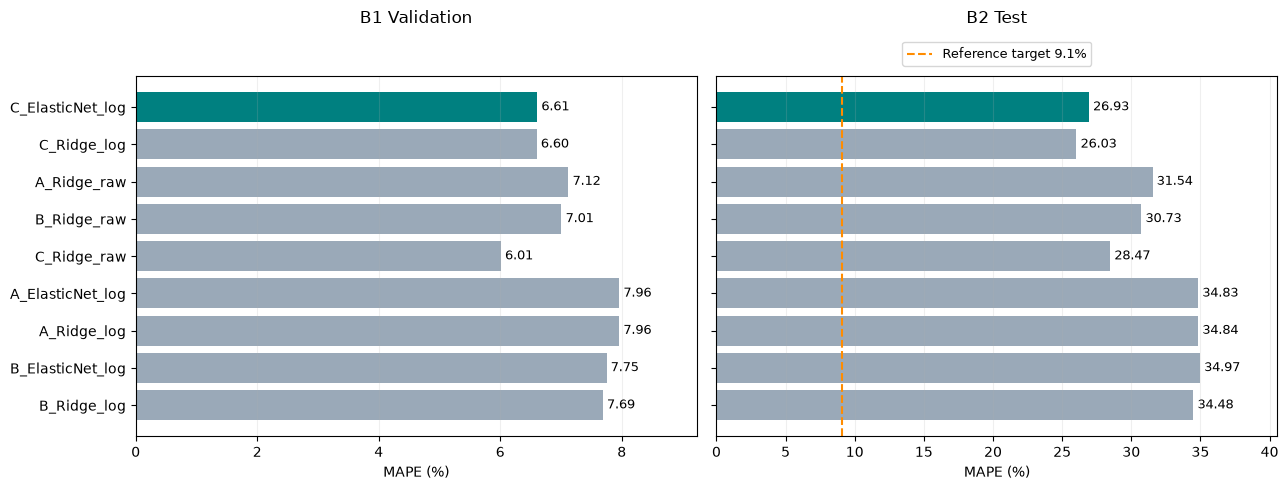

In [18]:
plot_table = comparison.set_index("experiment_id")
colors = ["teal" if name == selected_experiment_id else "#9AA9B8" for name in plot_table.index]
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, metric, title in zip(axes, ["Valid_MAPE_pct", "Test_MAPE_pct"], ["B1 Validation", "B2 Test"]):
    bars = ax.barh(plot_table.index, plot_table[metric], color=colors)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
    ax.set(xlabel="MAPE (%)", xlim=(0, plot_table[metric].max() * 1.16))
    ax.set_title(title, pad=38)
    ax.grid(axis="x", alpha=0.2)
axes[0].invert_yaxis()
axes[1].axvline(PAPER_TARGET_MAPE, color="darkorange", linestyle="--", label="Reference target 9.1%")
axes[1].legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), fontsize=9)
fig.tight_layout()
fig.savefig(OUT / "validation_test_comparison.png", dpi=150)
plt.show()

막대가 짧을수록 오차가 작습니다. 청록색은 개발 CV 후보입니다.
왼쪽·오른쪽은 서로 다른 데이터이므로 각 축의 숫자를 함께 읽으세요.
Test의 점선 9.1%는 과제의 참고 목표이며, 논문과 로컬 데이터의 조건이 달라 동일 실험의 재현값은 아닙니다.

## 9. 제출용 nested CV — 선택과 평가를 분리

아래까지 실행해야 제출용 Train CV가 계산됩니다.
개발 36셀에서 **바깥 5-fold 평가 / 바깥 학습 안의 안쪽 3-fold 선택**을 적용합니다.
① 각 고정 피처·모델의 설정 선택 성능과 ② 9조합 전체를 선택하는 절차의 성능을 함께 보관합니다.
긴 보조 함수는 접고 출력부터 읽어도 됩니다.

In [19]:
def fold_membership(frame, splits, outer_fold=None):
    rows = []
    for fold, (fit_idx, check_idx) in enumerate(splits, start=1):
        assert set(frame.iloc[fit_idx]["policy_group"]).isdisjoint(set(frame.iloc[check_idx]["policy_group"]))
        for role, indices in [("train", fit_idx), ("validation", check_idx)]:
            for position in indices:
                rows.append({"outer_fold": outer_fold, "fold": fold, "role": role,
                             "cell_uid": frame.iloc[position]["cell_uid"],
                             "policy_group": frame.iloc[position]["policy_group"]})
    return pd.DataFrame(rows)

outer_splits = list(GroupKFold(n_splits=5).split(df_train, y_train, groups_train))
shared_tuning_membership = fold_membership(df_train, shared_cv_splits)
shared_outer_membership = fold_membership(df_train, outer_splits)
print("바깥 평가:", len(outer_splits), "fold / 각 바깥 학습의 안쪽 설정 선택: 3 fold")

바깥 평가: 5 fold / 각 바깥 학습의 안쪽 설정 선택: 3 fold


<details><summary>보조 코드: 공통 nested CV 분할을 기록합니다</summary>

각 셀이 어느 폴드의 학습·검증에 들어갔는지 저장합니다. 모든 실험에서 **동일한 바깥·안쪽 분할**을 사용합니다.
정책 그룹이 겹치지 않는지 다시 확인합니다. 바깥 검증에는 개발 데이터의 각 셀이 한 번씩 들어갑니다.
Validation 10셀과 Batch 2는 이 CV 계산에 포함하지 않습니다.

</details>

In [20]:
def evaluate_outer_fold(outer_fold, fit_idx, check_idx):
    fit_frame = df_train.iloc[fit_idx].reset_index(drop=True)
    check_frame = df_train.iloc[check_idx].reset_index(drop=True)
    inner_splits = list(GroupKFold(n_splits=3).split(fit_frame, fit_frame[TARGET], fit_frame["policy_group"]))
    membership = fold_membership(fit_frame, inner_splits, outer_fold)
    scores, predictions, inner_trials, candidates = [], [], [], []
    for experiment in experiments:
        exp_id = experiment["experiment_id"]
        features = FEATURE_SETS[experiment["feature_key"]]
        trials, inner_scores, params = search_settings(experiment, fit_frame, inner_splits)
        trials["outer_fold"] = outer_fold
        inner_trials.append(trials)
        model = make_model(experiment, params)
        model.fit(fit_frame[features], fit_frame[TARGET])
        prediction = model.predict(check_frame[features])
        scores.append({"experiment_id": exp_id, "outer_fold": outer_fold,
                       "params_json": json.dumps(params, sort_keys=True), "valid_cells": len(check_frame),
                       **evaluate(check_frame[TARGET], prediction)})
        frame = check_frame[["cell_uid", "policy_group", TARGET]].copy()
        frame["experiment_id"], frame["outer_fold"], frame["predicted"] = exp_id, outer_fold, prediction
        predictions.append(frame)
        candidates.append((inner_scores.iloc[0]["Tuning_CV_MAPE_pct"], experiment["n_inputs"], exp_id))
    inner_score, _, winner = min(candidates)  # 전체 선택도 바깥 검증을 보기 전에 완료
    winner_score = next(row for row in scores if row["experiment_id"] == winner).copy()
    winner_score.update({"selected_experiment_id": winner, "inner_selection_MAPE_pct": inner_score,
                         "experiment_id": "ALL_9_SELECTION"})
    winner_predictions = next(frame for frame in predictions if frame["experiment_id"].iloc[0] == winner).copy()
    winner_predictions["selected_experiment_id"], winner_predictions["experiment_id"] = winner, "ALL_9_SELECTION"
    return scores, predictions, inner_trials, membership, winner_score, winner_predictions

<details><summary>보조 코드: 바깥 폴드 하나에서 무슨 일이 일어나나요?</summary>

1. 바깥 학습 데이터 안에서만 3-fold 설정 탐색을 합니다. 매번 전처리도 해당 학습 폴드에서 다시 학습합니다.
2. 각 실험의 선택 설정으로 바깥 학습을 재학습한 뒤, 바깥 검증을 한 번 예측합니다.
3. 9조합 전체 선택 절차는 **안쪽 점수**만으로 피처·모델·설정까지 고릅니다.
4. 그 후보의 바깥 예측은 이미 만든 동일 모델의 예측을 사용합니다. 바깥 검증 점수로 승자를 고르지 않습니다.

`ALL_9_SELECTION`은 단일 고정 모델 이름이 아니라 **9조합에서 고르는 전체 절차**를 뜻합니다.
바깥 폴드마다 선택된 피처·모델·alpha가 달라도 정상입니다.

</details>

In [21]:
nested_rows, nested_prediction_frames, nested_inner_frames, nested_membership_frames = [], [], [], []
global_rows, global_prediction_frames = [], []
for outer_fold, (fit_idx, check_idx) in enumerate(outer_splits, start=1):
    rows, frames, trials, membership, winner_row, winner_frame = evaluate_outer_fold(outer_fold, fit_idx, check_idx)
    nested_rows.extend(rows)
    nested_prediction_frames.extend(frames)
    nested_inner_frames.extend(trials)
    nested_membership_frames.append(membership)
    global_rows.append(winner_row)
    global_prediction_frames.append(winner_frame)
nested_fold_scores = pd.DataFrame(nested_rows)
nested_oof_predictions = pd.concat(nested_prediction_frames, ignore_index=True)
nested_inner_trials = pd.concat(nested_inner_frames, ignore_index=True)
shared_inner_membership = pd.concat(nested_membership_frames, ignore_index=True)
global_fold_scores = pd.DataFrame(global_rows)
global_oof_predictions = pd.concat(global_prediction_frames, ignore_index=True)
for _, frame in nested_oof_predictions.groupby("experiment_id"):
    assert len(frame) == 36 and frame["cell_uid"].is_unique
assert len(global_oof_predictions) == 36 and global_oof_predictions["cell_uid"].is_unique
display(global_fold_scores[["outer_fold", "selected_experiment_id", "params_json", "MAPE_pct"]].round(4))

,outer_fold,selected_experiment_id,params_json,MAPE_pct
0,1,B_ElasticNet_log,"{""alpha"": 0.01, ""l1_ratio"": 0.1}",17.6408
1,2,C_ElasticNet_log,"{""alpha"": 0.0001, ""l1_ratio"": 0.1}",10.4031
2,3,C_ElasticNet_log,"{""alpha"": 0.01, ""l1_ratio"": 0.9}",9.8679
3,4,C_Ridge_log,"{""alpha"": 1.0}",11.4421
4,5,C_ElasticNet_log,"{""alpha"": 0.01, ""l1_ratio"": 0.9}",2.3516


<details><summary>보조 코드: 5번 반복 결과를 어떻게 모으나요?</summary>

바깥 5개 폴드마다 고정 실험 9개와 전체 선택 절차를 평가합니다.
`OOF`는 각 셀이 그 셀을 학습하지 않은 바깥 모델에서 얻은 예측값입니다.
각 고정 실험과 전체 선택 절차 모두 개발 36셀에 대해 중복 없는 OOF를 확인했습니다.
위 출력은 전체 선택 절차가 각 바깥 학습에서 선택한 조합과, 이후 얻은 바깥 MAPE입니다.

</details>

In [22]:
nested_summary = nested_fold_scores.groupby("experiment_id", as_index=False).agg(
    Nested_CV_MAPE_pct=("MAPE_pct", "mean"), Nested_CV_MAPE_std_pp=("MAPE_pct", "std"))
global_nested_summary = pd.DataFrame([{
    "procedure": "Select features + model + settings among all 9 on inner CV",
    "Nested_CV_MAPE_pct": global_fold_scores["MAPE_pct"].mean(),
    "Nested_CV_MAPE_std_pp": global_fold_scores["MAPE_pct"].std(),
}])
comparison = comparison.merge(nested_summary, on="experiment_id", validate="one_to_one")
display(comparison[["experiment_id", "Nested_CV_MAPE_pct", "Valid_MAPE_pct", "Test_MAPE_pct", "CV_candidate"]].round(3))
display(global_nested_summary.round(3))

,experiment_id,Nested_CV_MAPE_pct,Valid_MAPE_pct,Test_MAPE_pct,CV_candidate
0,C_ElasticNet_log,7.990,6.608,26.933,True
1,C_Ridge_log,7.996,6.599,26.031,False
2,A_Ridge_raw,9.589,7.122,31.537,False
3,B_Ridge_raw,9.781,7.007,30.725,False
4,C_Ridge_raw,9.269,6.010,28.472,False
5,A_ElasticNet_log,12.375,7.958,34.834,False
6,A_Ridge_log,12.622,7.958,34.836,False
7,B_ElasticNet_log,13.001,7.750,34.966,False
8,B_Ridge_log,12.807,7.688,34.485,False


,procedure,Nested_CV_MAPE_pct,Nested_CV_MAPE_std_pp
0,Select features + model + settings among all 9...,10.341,5.444


첫 표의 `Nested_CV_MAPE_pct`는 **각 피처·모델을 고정하고 설정만 선택하는 절차**의 바깥 폴드 MAPE 평균입니다.
이는 설정을 고를 때 사용한 `Tuning_CV`와 다릅니다. 36개 OOF의 MAPE를 한 번 계산한 값과도 다를 수 있습니다.
둘째 표는 **9조합 전체를 선택하는 절차**를 평가한 점수입니다.
최종 CV 후보를 9개 중 고른 뒤 그 후보의 고정 실험 점수만 보면 전체 선택 과정이 반영되지 않으므로 두 점수를 구분합니다.
이 nested 결과로 앞에서 고정한 배포 후보나 설정을 다시 선택하지 않습니다.

## 10. 과제의 6행 표 — 보고할 실험을 골라 보기

In [23]:
report_rows = []
for _, row in comparison.iterrows():
    cv, valid, test = row["Nested_CV_MAPE_pct"], row["Valid_MAPE_pct"], row["Test_MAPE_pct"]
    values = [cv, valid, test, valid - cv, test - valid, test - PAPER_TARGET_MAPE]
    items = ["Train (Batch 1 CV)", "Valid (Batch 1 Hold-out)", "Test (Batch 2)",
             "GAP (Train-Valid)", "GAP (Valid-Test)", "GAP (Target-Test)"]
    formulas = ["바깥 5-fold MAPE 산술평균", "고정 설정의 B1 hold-out MAPE", "B1 전체 재학습 후 B2 MAPE",
                "Valid − Train CV", "Test − Valid", "Test − 9.1%"]
    meanings = ["고정 피처·모델의 설정 선택 절차 평가", "학습에 쓰지 않은 정책 10셀 평가", "배치가 달라진 외부 평가",
                "양수면 오차 증가: 과적합 의심 신호", "양수면 배치 일반화 성능 저하", "양수면 참고 목표보다 큰 오차"]
    for i, (item, value) in enumerate(zip(items, values)):
        report_rows.append({"experiment_id": row["experiment_id"], "item": item, "value": value,
                            "unit": "%" if i < 3 else "%p", "calculation": formulas[i], "interpretation": meanings[i]})
day2_reports_all = pd.DataFrame(report_rows)

위 코드는 **각 실험을 고정했을 때의** nested CV·Validation·Test와 GAP을 6행씩 만듭니다.
Train은 해당 피처·모델을 고정하고 설정만 고르는 nested CV의 바깥 폴드 MAPE 평균입니다.
9개 실험의 54행 표는 `day2_reports_all.csv`로 보관합니다.
다음 셀에서는 고정 실험을 보고할지, 9조합 전체 선택 절차를 보고할지 구분합니다.

In [24]:
global_cv = float(global_nested_summary.iloc[0]["Nested_CV_MAPE_pct"])
cv_selected_report = day2_reports_all.loc[
    day2_reports_all["experiment_id"].eq(selected_experiment_id)].copy()
selected_valid = float(cv_selected_report.loc[cv_selected_report["item"].eq("Valid (Batch 1 Hold-out)"), "value"].iloc[0])
train_row = cv_selected_report["item"].eq("Train (Batch 1 CV)")
gap_row = cv_selected_report["item"].eq("GAP (Train-Valid)")
cv_selected_report.loc[train_row, "value"] = global_cv
cv_selected_report.loc[train_row, "calculation"] = "전체 9조합 선택 절차의 바깥 5-fold MAPE 평균"
cv_selected_report.loc[train_row, "interpretation"] = "피처·모델·설정을 안쪽 CV에서 함께 선택한 절차 평가"
cv_selected_report.loc[gap_row, "value"] = selected_valid - global_cv
if EXPERIMENT_TO_REPORT == "CV_SELECTED":
    report_experiment, report_mode = selected_experiment_id, "ALL_9_SELECTION"
    day2_report = cv_selected_report.copy()
else:
    report_experiment, report_mode = EXPERIMENT_TO_REPORT, "FIXED_EXPERIMENT"
    if report_experiment not in experiment_lookup:
        raise ValueError(f"CV_SELECTED 또는 다음 실험 이름을 사용하세요: {list(experiment_lookup)}")
    day2_report = day2_reports_all.loc[day2_reports_all["experiment_id"].eq(report_experiment)].copy()
print("보고 모드:", report_mode, "/ 최종 실험:", report_experiment, "/ 설정:", best_params[report_experiment])
display(day2_report.drop(columns="experiment_id").round(3))

보고 모드: ALL_9_SELECTION / 최종 실험: C_ElasticNet_log / 설정: {'alpha': 0.01, 'l1_ratio': 0.9}


,item,value,unit,calculation,interpretation
0,Train (Batch 1 CV),10.341,%,전체 9조합 선택 절차의 바깥 5-fold MAPE 평균,피처·모델·설정을 안쪽 CV에서 함께 선택한 절차 평가
1,Valid (Batch 1 Hold-out),6.608,%,고정 설정의 B1 hold-out MAPE,학습에 쓰지 않은 정책 10셀 평가
2,Test (Batch 2),26.933,%,B1 전체 재학습 후 B2 MAPE,배치가 달라진 외부 평가
3,GAP (Train-Valid),-3.733,%p,Valid − Train CV,양수면 오차 증가: 과적합 의심 신호
4,GAP (Valid-Test),20.325,%p,Test − Valid,양수면 배치 일반화 성능 저하
5,GAP (Target-Test),17.833,%p,Test − 9.1%,양수면 참고 목표보다 큰 오차


기본값 `CV_SELECTED`의 **Train은 9조합 전체 선택 절차**의 nested CV 바깥 5개 폴드 MAPE 평균입니다.
Valid/Test는 개발 CV에서 고정한 최종 후보의 평가값입니다. 바깥 CV에서는 매 폴드의 학습 데이터로 후보를 고릅니다.
`EXPERIMENT_TO_REPORT="B_Ridge_raw"`처럼 실험 이름을 지정하면 **그 피처·모델을 고정하고 설정만 선택한** Train 평균을 씁니다.
두 보고 방식 모두 Train에 튜닝 점수를 사용하지 않습니다. 후보가 좋아 보이는 고정 실험 점수와 전체 선택 점수를 혼동하지 마세요.
GAP은 다음 단계 오차에서 앞 단계 오차를 뺀 값이며 단위는 `%p`입니다.
Train→Valid 양수는 오차가 늘었다는 신호이고, 표본 수·분할 차이 때문에 이것만으로 과적합을 확정하지 않습니다.
Valid→Test 양수는 배치가 바뀌었을 때 오차 증가, Target→Test 양수는 9.1% 참고 목표 초과를 뜻합니다.
전체 선택 절차의 점수와 고정 실험 점수는 위의 `global_nested_summary`와 9행 표에서도 따로 확인할 수 있습니다.

## 11. 결과와 재현 정보 저장

In [25]:
split_frames = []
for name, frame in [("B1 development", df_train), ("B1 hold-out", df_valid), ("B2 external evaluation", df_test)]:
    membership = frame[["cell_uid", "batch_id", "policy_group", TARGET]].copy()
    membership["split"] = name
    split_frames.append(membership)
split_membership = pd.concat(split_frames, ignore_index=True)
outputs = {
    "comparison.csv": comparison, "experiment_catalog.csv": experiment_catalog,
    "tuning_trials.csv": tuning_trials, "tuning_scores.csv": tuning_scores, "tuning_choices.csv": tuning_choices,
    "split_membership.csv": split_membership, "cohort_audit.csv": cohort_audit, "excluded_cells.csv": excluded_cells,
    "validation_metrics.csv": validation_metrics, "test_metrics.csv": test_metrics,
    "validation_predictions.csv": validation_predictions, "test_predictions.csv": test_predictions,
    "shared_tuning_fold_membership.csv": shared_tuning_membership,
    "shared_nested_outer_membership.csv": shared_outer_membership, "shared_nested_inner_membership.csv": shared_inner_membership,
    "nested_inner_trials.csv": nested_inner_trials, "nested_fold_scores.csv": nested_fold_scores,
    "nested_oof_predictions.csv": nested_oof_predictions, "nested_summary.csv": nested_summary,
    "global_nested_fold_scores.csv": global_fold_scores, "global_nested_oof_predictions.csv": global_oof_predictions,
    "global_nested_summary.csv": global_nested_summary,
    "day2_reports_all.csv": day2_reports_all, "day2_report.csv": day2_report,
    "day2_global_selection_report.csv": cv_selected_report,
}
for filename, frame in outputs.items():
    frame.to_csv(OUT / filename, index=False, encoding="utf-8-sig")
print("저장한 CSV:", len(outputs), "/ 폴더:", OUT)

저장한 CSV: 25 / 폴더: /Users/suyeong/Downloads/archive/Modeling/results/feature_model_validation


비교표뿐 아니라 **설정 선택 과정·공통 분할·제외 이유·각 셀의 예측·nested CV**를 함께 저장합니다.
`day2_report.csv`는 현재 보고 모드의 6행, `day2_reports_all.csv`는 고정 실험 9개의 6행을 세로로 저장한 파일입니다.
`day2_global_selection_report.csv`는 전체 9조합 선택 절차를 보고하는 6행 표입니다.
`comparison.csv`에는 튜닝 CV와 제출용 nested CV가 모두 들어 있으며 두 점수의 열 이름을 구분했습니다.
이 출력은 원본 데이터나 기존 `02`의 산출물을 바꾸지 않습니다.

In [26]:
save_ids = sorted({selected_experiment_id, "B_Ridge_raw"})
model_files = {}
for exp_id in save_ids:
    filename = f"{exp_id}.joblib"
    joblib.dump(final_models[exp_id], OUT / filename)
    model_files[exp_id] = filename
config = {
    "feature_sets": FEATURE_SETS, "model_specs": MODEL_SPECS, "target": TARGET, "seed": SEED,
    "selected_experiment_id": selected_experiment_id, "best_params": best_params,
    "selection_metric": "Development 3-fold group CV mean MAPE", "holdout_or_test_used_for_selection": False,
    "report_experiment": report_experiment, "report_mode": report_mode,
    "reporting_metric": "All-nine-selection nested CV" if report_mode == "ALL_9_SELECTION" else "Fixed-experiment nested CV",
    "global_reporting_metric": "All-nine-selection nested 5x3 group CV mean outer-fold MAPE",
    "B1_development_cells": len(df_train), "B1_holdout_cells": len(df_valid), "final_fit_B1_cells": len(batch1),
    "B2_evaluation_cells": len(df_test), "B3_used_for_training_or_evaluation": False,
    "policy_metadata_used_as_predictor": False, "official_cell_merge_applied": False,
    "holdout_and_B2_previously_viewed": True, "paper_target_mape_percent": PAPER_TARGET_MAPE,
    "cohort_note": "Raw local cohort; B2 is 2018-02-20, and 9.1% is a reference target.",
    "source_sha256": {name: hashlib.sha256((SOURCE / name).read_bytes()).hexdigest()
                      for name in ["cell_metadata.csv", "delta_q_features.csv", "current_features.csv"]},
    "model_files": model_files,
}
(OUT / "model_config.json").write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")
print("저장 모델:", model_files)
print("최종 CV 후보:", selected_experiment_id, "/ 입력:", FEATURE_SETS[experiment_lookup[selected_experiment_id]["feature_key"]])

저장 모델: {'B_Ridge_raw': 'B_Ridge_raw.joblib', 'C_ElasticNet_log': 'C_ElasticNet_log.joblib'}
최종 CV 후보: C_ElasticNet_log / 입력: ['delta_q_min', 'SOC_switch_pct']


개발 CV 후보와 기존 2피처 원수명 Ridge의 **Batch 1 전체 학습 모델**을 저장합니다.
저장된 Pipeline/로그 수명 래퍼는 원래 입력 열을 받아 결측 처리·표준화·필요한 역변환까지 수행합니다.
설정 파일에는 입력 CSV의 SHA256과 분할·선택 원칙을 기록해 결과의 출처를 확인할 수 있습니다.

## 결과 해석의 범위와 직접 해보기

- 공식 셀 병합·수명 보정 없이 로컬 원본 수명을 사용했습니다. 로컬 Batch 2는 2018-02-20이며 논문 코호트와 다릅니다.
- hold-out과 Batch 2는 이전 EDA·실험에서 확인했습니다. 이번 검증을 완전히 새로운 데이터의 독립 평가로 해석하지 않습니다.
- 공통 그룹 분할은 충전 정책의 중복을 막으며, 배치 간 물리적 셀 대응이 모두 확인되었다는 뜻은 아닙니다.
- 로그 수명과 ElasticNet을 추가해도 개선이 보장되지 않습니다. CV·Validation·Test의 방향이 일치하는지 읽으세요.

1. `EXPERIMENT_TO_REPORT="B_Ridge_raw"`로 기존 2피처 구성의 6행 표를 확인해 보세요.
2. B와 C의 같은 모델을 비교하며 SOC는 유지하고 ΔQ 표현만 바꾼 효과를 설명해 보세요.
3. 원수명/로그 수명의 같은 피처 구성을 비교하며 역변환 후 MAPE와 사이클 오차가 어떻게 달라지는지 읽어 보세요.

설정을 바꿀 때는 **Restart Kernel → Run All**로 재현합니다. Test를 보고 설정을 바꾸면 이후 같은 Test 결과는 재평가로 기록합니다.